In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from itertools import product
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import dwave_nl_sharpe
#from optimization_engines import dwave_cqm_qubo, genetic_algorithm_qubo

# Load D-Wave API token from .env file
from dotenv import load_dotenv
load_dotenv()

# Set D-Wave token as environment variable
if 'DWAVE_API_TOKEN' in os.environ:
    os.environ['DWAVE_API_TOKEN'] = os.environ['DWAVE_API_TOKEN']
    print("✅ D-Wave API token loaded successfully")
else:
    print("❌ D-Wave API token not found in .env file")
from dimod import BinaryQuadraticModel, ConstrainedQuadraticModel, Binary, quicksum
from dwave.samplers import SimulatedAnnealingSampler, TabuSampler, SteepestDescentSampler
from dwave.system import LeapHybridBQMSampler, LeapHybridCQMSampler, LeapHybridSampler
from dimod import ExactSolver
from dwave.optimization import Model
from itertools import product
from dwave.optimization.mathematical import (
    maximum, minimum, sqrt, safe_divide, multiply, add,
    exp, log, absolute, where, logical_and, logical_or
)
SEED = 14
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

✅ D-Wave API token loaded successfully


## D-Wave Connection Test: QUBO Optimization (10 Stocks, Single Period)

In [2]:
# Create a logger
logger = logging.getLogger("dwave_test_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# Create a handler (where to send the logs)
handler = logging.StreamHandler()  # Send to the console
handler.setLevel(msg_level)

# Create a formatter (how to format the logs)
formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(handler)

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


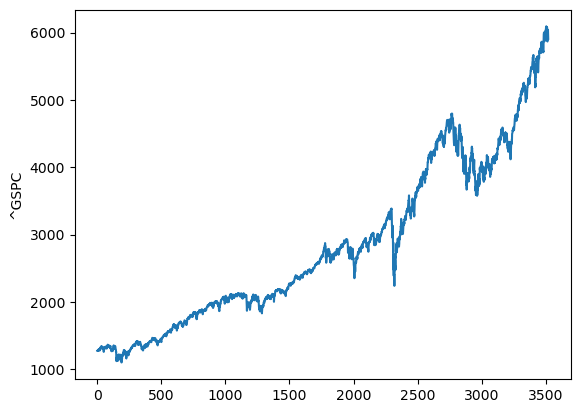

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Select 10 stocks for connection test

In [6]:
# Simplified stock selection - rank by correlation and returns
df_corr = source.corr()
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)

return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
select_10 = (return_rank + corr_rank).sort_values().reset_index()['Ticker'].values[:10]
print(f"Selected 10 stocks for test: {select_10}")

Selected 10 stocks for test: ['FICO' 'LLY' 'MCK' 'CHTR' 'GWW' 'AXON' 'REGN' 'RCL' 'RL' 'TSLA']


### Portfolio Stats

In [7]:
def portfolio_stats(weights, data):
    weights = np.array(weights)
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    port_return = np.sum(returns.mean() * weights) 
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    try:
        sharpe_ratio = port_return/port_vol
    except Exception as e:
        sharpe_ratio = 0
    return sharpe_ratio, port_return, port_vol

def qubo_fitness_function(weights, data, risk_level=0.5):
    """
    QUBO fitness function with fixed risk level.
    Maximizes: return - risk_level * variance
    """
    sharpe_ratio, port_return, port_vol = portfolio_stats(weights, data)
    portfolio_variance = port_vol ** 2
    objective = port_return - risk_level * portfolio_variance
    return objective

In [8]:
import gc
from dimod import BinaryQuadraticModel, ConstrainedQuadraticModel, Binary, quicksum
from dwave.samplers import SimulatedAnnealingSampler, TabuSampler, SteepestDescentSampler
from dwave.system import LeapHybridBQMSampler, LeapHybridCQMSampler, LeapHybridSampler
from dimod import ExactSolver
from dimod import Integer, Real

### Simple Single-Period Test Function

In [9]:
def single_period_test(optimization_function, data, test_name):
    """
    Simple single-period optimization test.
    
    Args:
        optimization_function: Function to test
        data: Stock price data
        test_name: Name for logging
    
    Returns:
        results: Dictionary with weights, stats, and timing
    """
    print(f"\n{'='*60}")
    print(f"TESTING: {test_name}")
    print(f"{'='*60}")
    
    # Use most recent 60 days of data for test
    test_data = data.iloc[:30, :]
    
#    try:
    start_time = datetime.now()
    print(f"Starting optimization at {start_time}...")
    
    # Run optimization
    weights = optimization_function(test_data)
    return weights 
    
    # end_time = datetime.now()
    # execution_time = (end_time - start_time).total_seconds()
    
    # # Check if weights is None
    # if weights is None:
    #     raise ValueError("Optimization function returned None weights")
    
    # # Calculate portfolio statistics
    # sharpe, port_return, port_vol = portfolio_stats(weights, test_data)
    # qubo_objective = qubo_fitness_function(weights, test_data, risk_level=0.5)
    
    # # Results summary
    # results = {
    #     'test_name': test_name,
    #     'weights': weights,
    #     'sharpe_ratio': sharpe,
    #     'portfolio_return': port_return,
    #     'portfolio_volatility': port_vol,
    #     'qubo_objective': qubo_objective,
    #     'execution_time': execution_time,
    #     'success': True,
    #     'error': None
    # }
    
    # print(f"✅ SUCCESS: {test_name}")
    # print(f"   Execution time: {execution_time:.2f}s")
    # print(f"   Sharpe ratio: {sharpe:.4f}")
    # print(f"   QUBO objective: {qubo_objective:.4f}")
    # print(f"   Portfolio return: {port_return:.4f}")
    # print(f"   Portfolio volatility: {port_vol:.4f}")
    # print(f"   Weights sum: {weights.sum():.6f}")
    # print(f"   All weights > 0: {all(w > 0 for w in weights)}")
    
    # return results
    
    # except Exception as e:
    #     end_time = datetime.now()
    #     execution_time = (end_time - start_time).total_seconds()
        
    #     results = {
    #         'test_name': test_name,
    #         'weights': None,
    #         'sharpe_ratio': None,
    #         'portfolio_return': None,
    #         'portfolio_volatility': None,
    #         'qubo_objective': None,
    #         'execution_time': execution_time,
    #         'success': False,
    #         'error': str(e)
    #     }
        
    #     print(f"❌ FAILED: {test_name}")
    #     print(f"   Execution time: {execution_time:.2f}s")
    #     print(f"   Error: {e}")
        
    #     return results

### Test Parameters

In [10]:
# Parameters for single-period connection test
test_parameters = {
    # BQM/CQM parameters
    "budget": 1_000_000.0,
    "min_investment": 0.001,
    
    # GA parameters  
    "population_size": 100,
    "num_generations": 50,
    "mutation_rate": 0.1,
    "elitism": 0.1,
}

print(f"Test parameters: {test_parameters}")

Test parameters: {'budget': 1000000.0, 'min_investment': 0.001, 'population_size': 100, 'num_generations': 50, 'mutation_rate': 0.1, 'elitism': 0.1}


### Connection Test: 10 Stocks Dataset

In [11]:
# # Prepare 10 stocks dataset
# #data_10 = source[select_10]
# data_10 = source.copy()
# #data_10 = source
# print(f"Test dataset shape: {data_10.shape}")
# print(f"Date range: {data_10.index[0]} to {data_10.index[-1]}")

# # Plot the data
# plt.figure(figsize=(12,6))
# sns.set_style('darkgrid')
# data_10.plot(figsize=(12,6))
# plt.title('10 Stocks Test Dataset')
# plt.legend(loc='upper left')
# plt.show()

#### Test 1: D-Wave CQM QUBO Optimization

In [12]:
from dwave.system.samplers import LeapHybridNLSampler

In [13]:
# Setup CQM optimization function


cqm_optimizer = partial(
    dwave_nl_sharpe,
    #cqm_fun, 
    budget=100_000_000,
    min_investment=0.0001
)

# Run CQM test
weights = single_period_test(
    cqm_optimizer, 
    source, 
    "D-Wave CQM QUBO Optimization"
)


TESTING: D-Wave CQM QUBO Optimization
Starting optimization at 2025-10-06 16:04:15.979919...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 100000000
  - Min Investment: 0.0001
  - Data shape: (30, 439)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CE', 'CF', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRL', 'CRM', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CT

In [14]:
print(weights)

[2.26365051e-01 1.07249416e-04 1.07249416e-04 3.38654707e-01
 1.07249416e-04 1.07249416e-04 1.45520310e-01 1.07249416e-04
 1.07249416e-04 1.07249416e-04 1.07249416e-04 1.07249416e-04
 9.04730379e-02 7.07065448e-03 1.07249416e-04 1.07249416e-04
 6.17395885e-02 1.07249416e-04 1.07249416e-04 1.07249416e-04
 1.77792315e-02 6.61772436e-02 1.07249416e-04 1.07249416e-04
 1.07249416e-04 1.07249416e-04 1.07249416e-04 1.07249416e-04
 1.07249416e-04 1.07249416e-04 1.07249416e-04 1.07249416e-04
 1.07249416e-04 1.07249416e-04 1.07249416e-04 1.07249416e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.07238692e-04 1.07238692e-04 1.07238692e-04
 1.07238692e-04 1.072386

Minimum weight: 0.0001072387
Maximum weight: 0.3386547067

Number of assets with weight > minimum: 36 out of 439
Percentage of assets above minimum: 8.20%

Top 10 allocations:
  Asset 3: 0.338655 (33.8655%)
  Asset 0: 0.226365 (22.6365%)
  Asset 6: 0.145520 (14.5520%)
  Asset 12: 0.090473 (9.0473%)
  Asset 21: 0.066177 (6.6177%)
  Asset 16: 0.061740 (6.1740%)
  Asset 20: 0.017779 (1.7779%)
  Asset 13: 0.007071 (0.7071%)
  Asset 31: 0.000107 (0.0107%)
  Asset 2: 0.000107 (0.0107%)


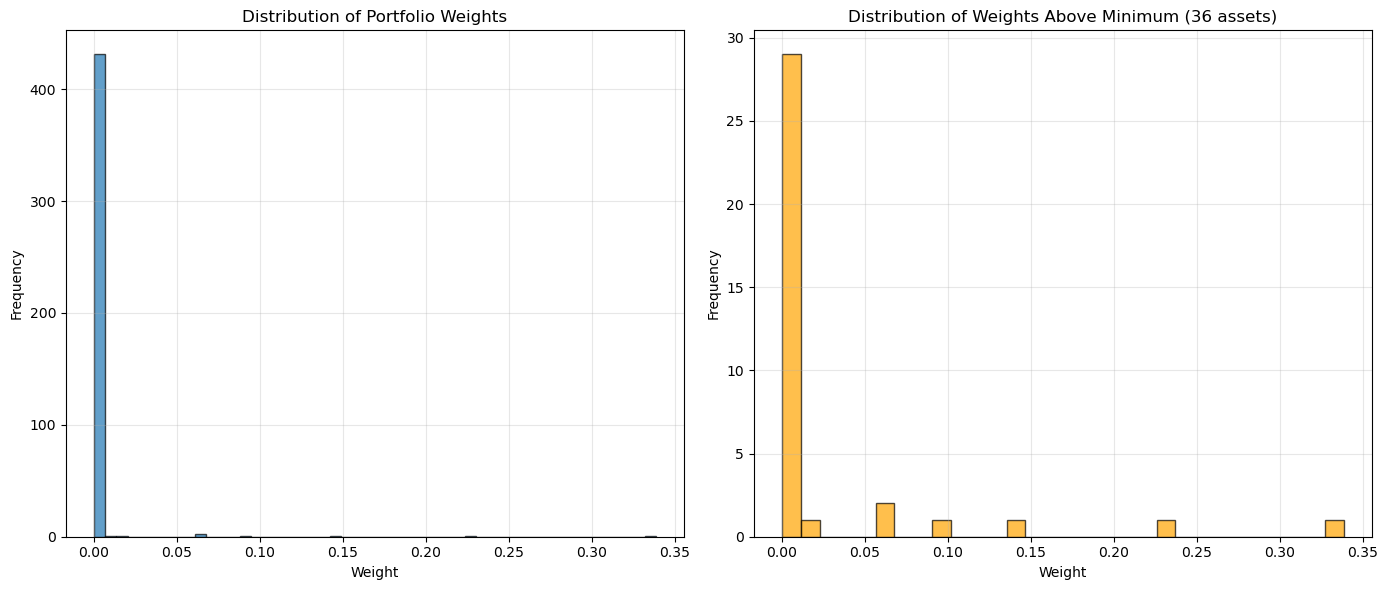

In [15]:
# Analysis of weights distribution
min_weight = weights.min()
print(f"Minimum weight: {min_weight:.10f}")
print(f"Maximum weight: {weights.max():.10f}")

# Count elements greater than minimum
num_greater_than_min = np.sum(weights > min_weight)
print(f"\nNumber of assets with weight > minimum: {num_greater_than_min} out of {len(weights)}")
print(f"Percentage of assets above minimum: {100 * num_greater_than_min / len(weights):.2f}%")

# Show top allocations
top_10_indices = np.argsort(weights)[-10:][::-1]
print(f"\nTop 10 allocations:")
for idx in top_10_indices:
    print(f"  Asset {idx}: {weights[idx]:.6f} ({100*weights[idx]:.4f}%)")

# Create histogram
plt.figure(figsize=(14, 6))

# Subplot 1: Full histogram
plt.subplot(1, 2, 1)
plt.hist(weights, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Distribution of Portfolio Weights')
plt.grid(True, alpha=0.3)

# Subplot 2: Log scale histogram (excluding minimum weights)
plt.subplot(1, 2, 2)
non_min_weights = weights[weights > min_weight]
plt.hist(non_min_weights, bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title(f'Distribution of Weights Above Minimum ({num_greater_than_min} assets)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()